In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("UpdatedResumeDataSet.csv")

In [5]:
df.head(5)

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [6]:
df.shape

(962, 2)

In [7]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64

In [12]:
df['Category'].nunique()

25

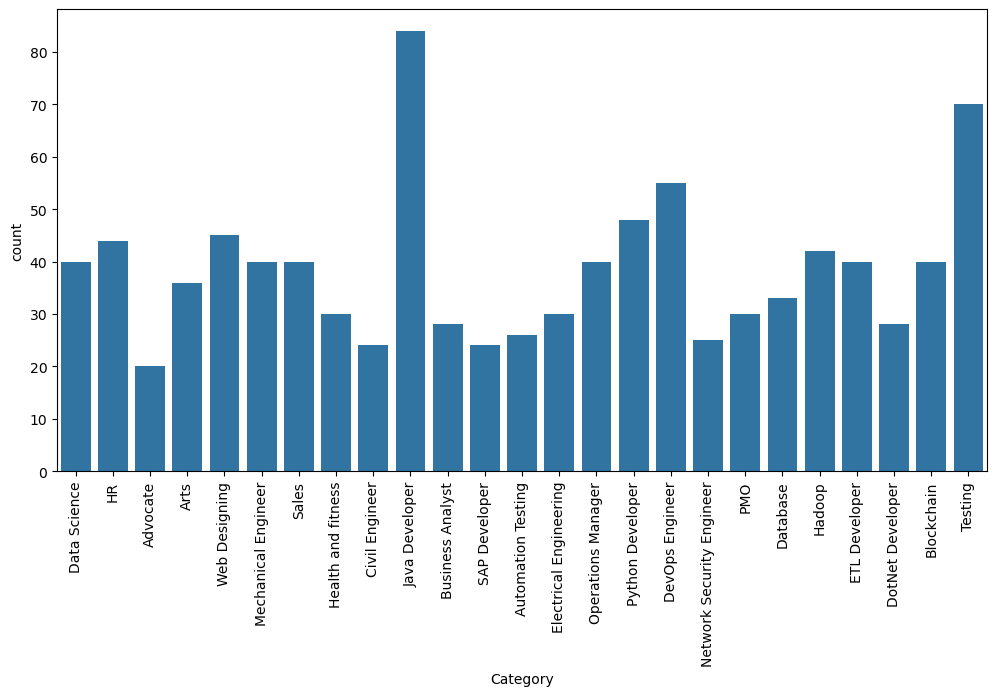

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Category', data=df)
plt.xticks(rotation=90)
plt.show()

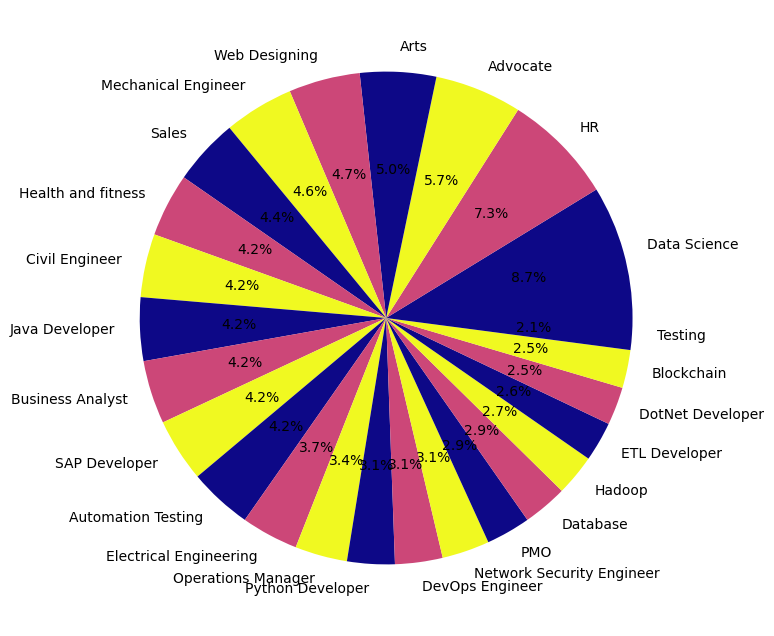

In [23]:
values= df['Category'].value_counts()
labels = df['Category'].unique()

plt.figure(figsize=(17,8))
plt.pie(values, labels=labels,autopct='%1.1f%%',colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

In [24]:
df['Category'][0]

'Data Science'

In [38]:
df['Resume'][0]

"Skill Set â\x80¢ Experience in Implementing, and troubleshooting network security solutions â\x80¢ Planning and Implementation knowledge of multi vendor firewalls (Cisco ASA, Checkpoint (Upto R.80) Juniper/Netscreen, Fortinet, FWSM) â\x80¢ Familiarity with the latest hardware and network security technologies â\x80¢ Excellent analytical and problem solving skills â\x80¢ Skilled in analyzing and monitoring network security solutions using a variety of Monitoring solutions (Zenoss, Solarwinds, Cisco Prime) â\x80¢ Work Experience on multi client data center environments. â\x80¢ Knowledge and Work experience on Firewall IOS Upgrade projects â\x80¢ Configuration of F5 load balancers, SSL certificate updates, I-Rule. F5 upgrades â\x80¢ Configuration of Cisco Routers ( series- 1800, 1900, 2500, 2600, 2800, 3600, Nexus - 5k, 7k) â\x80¢ Configuration of Cisco switches (series - 2960, 3750, catalyst, 4500, 3600) â\x80¢ Working knowledge of Bluecoat Proxy â\x80¢ Knowledge of ITIL process.Educati

In [37]:
print("Original Categories")
print(df["Category"].value_counts())
max_value= df["Category"].value_counts().max()

# # Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_value, replace=True)).reset_index(drop=True)

# # Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# # Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
 
print(df['Category'].value_counts())

Original Categories
Category
Health and fitness           84
Hadoop                       84
Arts                         84
PMO                          84
Business Analyst             84
Database                     84
Electrical Engineering       84
Operations Manager           84
Python Developer             84
Automation Testing           84
Advocate                     84
SAP Developer                84
Network Security Engineer    84
Web Designing                84
Java Developer               84
Blockchain                   84
DevOps Engineer              84
HR                           84
DotNet Developer             84
Testing                      84
Sales                        84
Civil Engineer               84
Data Science                 84
ETL Developer                84
Mechanical Engineer          84
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
Network Security Engineer    84
Java Developer               84
Civil Engineer    

C:\Users\Sufiyan Asif\AppData\Local\Temp\ipykernel_9220\2956511619.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_value, replace=True)).reset_index(drop=True)


In [40]:
import re
def cleanResume(text):
    cleanText = re.sub('http\S+\s', ' ', text)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)  
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

In [42]:
df['Resume'][0]

"Skill Set â\x80¢ Experience in Implementing, and troubleshooting network security solutions â\x80¢ Planning and Implementation knowledge of multi vendor firewalls (Cisco ASA, Checkpoint (Upto R.80) Juniper/Netscreen, Fortinet, FWSM) â\x80¢ Familiarity with the latest hardware and network security technologies â\x80¢ Excellent analytical and problem solving skills â\x80¢ Skilled in analyzing and monitoring network security solutions using a variety of Monitoring solutions (Zenoss, Solarwinds, Cisco Prime) â\x80¢ Work Experience on multi client data center environments. â\x80¢ Knowledge and Work experience on Firewall IOS Upgrade projects â\x80¢ Configuration of F5 load balancers, SSL certificate updates, I-Rule. F5 upgrades â\x80¢ Configuration of Cisco Routers ( series- 1800, 1900, 2500, 2600, 2800, 3600, Nexus - 5k, 7k) â\x80¢ Configuration of Cisco switches (series - 2960, 3750, catalyst, 4500, 3600) â\x80¢ Working knowledge of Bluecoat Proxy â\x80¢ Knowledge of ITIL process.Educati

In [43]:
df['Resume']= df['Resume'].apply(lambda x: cleanResume(x) )

In [44]:
df['Resume'][0]

'Skill Set Experience in Implementing and troubleshooting network security solutions Planning and Implementation knowledge of multi vendor firewalls Cisco ASA Checkpoint Upto R 80 Juniper Netscreen Fortinet FWSM Familiarity with the latest hardware and network security technologies Excellent analytical and problem solving skills Skilled in analyzing and monitoring network security solutions using a variety of Monitoring solutions Zenoss Solarwinds Cisco Prime Work Experience on multi client data center environments Knowledge and Work experience on Firewall IOS Upgrade projects Configuration of F5 load balancers SSL certificate updates I Rule F5 upgrades Configuration of Cisco Routers series 1800 1900 2500 2600 2800 3600 Nexus 5k 7k Configuration of Cisco switches series 2960 3750 catalyst 4500 3600 Working knowledge of Bluecoat Proxy Knowledge of ITIL process Education Details September 2006 to August 2011 Bachelor of Engineering BE Electronics Pune Maharashtra A I S S M S College of E

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
le= LabelEncoder()

In [47]:
le.fit(df['Category'])

LabelEncoder()

In [48]:
df['Category']= le.fit_transform(df['Category'])

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [50]:
tfidf.fit(df['Resume'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [53]:
Required_text = tfidf.transform(df['Resume'])

In [54]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(Required_text, df['Category'], test_size=0.2 , random_state= 42)

In [57]:
X_train.shape

(1680, 7408)

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [59]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [61]:
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

In [62]:
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [63]:
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9976
Confusion Matrix:
[[14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  1  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  